# 1. Imports

## 1.1 Bibliotecas

In [39]:
import pandas as pd
import sys
import os
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import geopandas as gpd
import plotly.graph_objects as go
import plotly.express as px


root_dir = os.path.abspath(os.path.join(os.path.dirname(os.getcwd()), '..', '..'))
sys.path.append(root_dir)

print(root_dir)

from src.utils.create_engine_postgres import create_engine_postgres

c:\ProjetosPython\WebScraping_Imobiliario


## 1.2 Tabelas

### 1.2.1 Tabela municipios

In [2]:
engine = create_engine_postgres(see_echo=False)

query = "SELECT * FROM silver.ibge01_municipios"
df_municipios = pd.read_sql(query, engine)

df_municipios.head()

,id,nome,microrregiao_id,microrregiao_nome,mesorregiao_id,mesorregiao_nome,uf_id,uf_sigla,uf_nome,regiao_id,regiao_sigla,regiao_nome
0,1400209,Caracarai,14003,Caracarai,1402,Sul de Roraima,14,RR,Roraima,1,N,Norte
1,1705557,Combinado,17008,Dianopolis,1702,Oriental do Tocantins,17,TO,Tocantins,1,N,Norte
2,2105104,Icatu,21003,Rosario,2101,Norte Maranhense,21,MA,Maranhao,2,NE,Nordeste
3,2930501,Serrinha,29016,Serrinha,2904,Nordeste Baiano,29,BA,Bahia,2,NE,Nordeste
4,3151305,Pirauba,31064,Uba,3112,Zona da Mata,31,MG,Minas Gerais,3,SE,Sudeste


### 1.2.2 Tabela de Imoveis

In [17]:
engine = create_engine_postgres(see_echo=False)

query = "SELECT * FROM gold.zapimoveis"
df_imoveis = pd.read_sql(query, engine)

df_imoveis.head()

,property_id,state_name,city_name,city_state_name,location,street,type_realese,area,rooms,bathrooms,price,link,update_at,year_update_at
0,2691091569,DF,Brasilia,Brasilia - DF,"Areal, Brasília",QS 5 Rua 300,Na planta,59,2,1,,https://www.zapimoveis.com.br/lancamento/venda...,2025-03-22 17:01:01+00:00,2025
1,2691089904,DF,Brasilia,Brasilia - DF,"Setor Habitacional Contagem, Brasília",Rodovia DF-425,Em construção,59,2,2,,https://www.zapimoveis.com.br/lancamento/venda...,2025-03-22 17:01:01+00:00,2025
2,2781601513,DF,Brasilia,Brasilia - DF,"Asa Sul, Brasília",EQS 414/415,Na planta,63,2,2,,https://www.zapimoveis.com.br/lancamento/venda...,2025-03-22 17:01:01+00:00,2025
3,2781604121,DF,Brasilia,Brasilia - DF,"Recanto das Emas, Brasília",Avenida Eucalipto Quadra 204,Em construção,60,2,1,,https://www.zapimoveis.com.br/lancamento/venda...,2025-03-22 17:01:01+00:00,2025
4,2689054138,DF,Brasilia,Brasilia - DF,"Recanto das Emas, Brasília",Avenida Recanto das Emas Quadra 201,Na planta,41,2,1,,https://www.zapimoveis.com.br/lancamento/venda...,2025-03-22 17:01:01+00:00,2025


### 1.2.3 Tabela de resumo

In [51]:
engine = create_engine_postgres(see_echo=False)

query = "SELECT * FROM gold.vi_imoveis_ibge"
df = pd.read_sql(query, engine)

df.head()

,state_name,city_name,update_at_imoveis,qtd_imoveis,qtd_type_realese_planta,qtd_type_realese_construcao,qtd_type_realese_pronto,qtd_type_realese_outros,qtd_imoveis_price,avg_price,...,unidades_locais_value,pessoal_ocupado_year,pessoal_ocupado_unidade,pessoal_ocupado_value,salario_medio_year,salario_medio_unidade,salario_medio_value,ensino_superior_year,ensino_superior_unidade,ensino_superior_value
0,AM,Manaus,2025-03-22 17:01:01+00:00,8,3,4,1,0,6,317177.67,...,74305.0,2022,Pessoas,636830.0,2022,Reais,3510.66,2022,Pessoas,258300.0
1,BA,Salvador,2025-03-22 17:01:01+00:00,16,7,7,2,0,11,461224.64,...,107314.0,2022,Pessoas,913748.0,2022,Reais,3716.38,2022,Pessoas,374042.0
2,CE,Fortaleza,2025-03-22 17:01:01+00:00,13,7,5,1,0,9,330272.44,...,122522.0,2022,Pessoas,951646.0,2022,Reais,3398.34,2022,Pessoas,362155.0
3,DF,Brasilia,2025-03-22 17:01:01+00:00,23,10,12,1,0,3,1065777.33,...,190432.0,2022,Pessoas,1427471.0,2022,Reais,5902.12,2022,Pessoas,716719.0
4,ES,Vitoria,2025-03-22 17:01:01+00:00,1,0,1,0,0,1,1202500.00,...,36484.0,2022,Pessoas,262574.0,2022,Reais,4536.97,2022,Pessoas,98406.0


# 2. Análise Exploratória

## 2.1 Tabela municipios

### 2.1.1 Visão Geral

In [18]:
df_municipios.describe(include='all').round(2)

,id,nome,microrregiao_id,microrregiao_nome,mesorregiao_id,mesorregiao_nome,uf_id,uf_sigla,uf_nome,regiao_id,regiao_sigla,regiao_nome
count,5570.00,5570,5570,5570,5570.00,5570,5570.00,5570,5570,5570.00,5570,5570
unique,NaN,5289,558,554,NaN,137,NaN,27,27,NaN,5,5
top,NaN,Bom Jesus,29031,Ilheus-Itabuna,NaN,Noroeste Rio-grandense,NaN,MG,Minas Gerais,NaN,NE,Nordeste
freq,NaN,5,41,41,NaN,216,NaN,853,853,NaN,1794,1794
mean,3253590.77,NaN,NaN,NaN,3242.04,NaN,32.38,NaN,NaN,2.90,NaN,NaN
std,984910.34,NaN,NaN,NaN,983.64,NaN,9.83,NaN,NaN,1.09,NaN,NaN
min,1100015.00,NaN,NaN,NaN,1101.00,NaN,11.00,NaN,NaN,1.00,NaN,NaN
25%,2512125.75,NaN,NaN,NaN,2503.00,NaN,25.00,NaN,NaN,2.00,NaN,NaN
50%,3146280.00,NaN,NaN,NaN,3110.00,NaN,31.00,NaN,NaN,3.00,NaN,NaN
75%,4119189.50,NaN,NaN,NaN,4106.00,NaN,41.00,NaN,NaN,4.00,NaN,NaN


###  2.1.2 Tipos das colunas

In [19]:
df_municipios.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5570 entries, 0 to 5569
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   id                 5570 non-null   int64 
 1   nome               5570 non-null   object
 2   microrregiao_id    5570 non-null   object
 3   microrregiao_nome  5570 non-null   object
 4   mesorregiao_id     5570 non-null   int64 
 5   mesorregiao_nome   5570 non-null   object
 6   uf_id              5570 non-null   int64 
 7   uf_sigla           5570 non-null   object
 8   uf_nome            5570 non-null   object
 9   regiao_id          5570 non-null   int64 
 10  regiao_sigla       5570 non-null   object
 11  regiao_nome        5570 non-null   object
dtypes: int64(4), object(8)
memory usage: 522.3+ KB


### 2.1.3 Valores Nulos

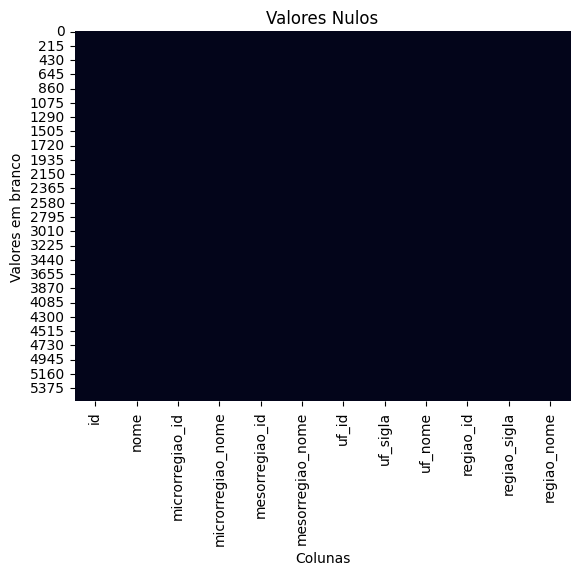

,Coluna,Tipo,Valores_Nulos,Percentual_Nulos
id,id,int64,0,0.0
nome,nome,object,0,0.0
microrregiao_id,microrregiao_id,object,0,0.0
microrregiao_nome,microrregiao_nome,object,0,0.0
mesorregiao_id,mesorregiao_id,int64,0,0.0
mesorregiao_nome,mesorregiao_nome,object,0,0.0
uf_id,uf_id,int64,0,0.0
uf_sigla,uf_sigla,object,0,0.0
uf_nome,uf_nome,object,0,0.0
regiao_id,regiao_id,int64,0,0.0


In [30]:
ax = plt.axes()
sns.heatmap(df_municipios.isna(), cbar=False, ax=ax)
plt.title("Valores Nulos", fontsize=12)
plt.xlabel('Colunas', fontsize = 10) 
plt.ylabel('Valores em branco', fontsize = 10)
plt.show()

null_analysis = pd.DataFrame({
        'Coluna': df_municipios.columns,
        'Tipo': df_municipios.dtypes,
        'Valores_Nulos': df_municipios.isnull().sum(),
        'Percentual_Nulos': (df_municipios.isnull().sum() / len(df_municipios)) * 100
    })

null_analysis.sort_values('Percentual_Nulos', ascending=False)

## 2.2 Tabela de Imoveis

### 2.2.1 Visão Geral

In [117]:
df_imoveis.describe(include='all').round(2).head(5)

,property_id,state_name,city_name,city_state_name,location,street,type_realese,area,rooms,bathrooms,price,link,update_at,year_update_at
count,1.341000e+03,1341,1341,1341,1341,1341,1341,1341.00,1341,1341,1005.00,1341,1341,1341.0
unique,NaN,18,18,18,359,777,3,NaN,6,7,NaN,1341,NaN,NaN
top,NaN,SP,Sao Paulo,Sao Paulo - SP,"Vila Mariana, São Paulo",Rua Fortunato Ferraz,Na planta,NaN,2,1,NaN,https://www.zapimoveis.com.br/lancamento/venda...,NaN,NaN
freq,NaN,783,783,783,54,17,530,NaN,607,575,NaN,1,NaN,NaN
mean,2.695848e+09,NaN,NaN,NaN,NaN,NaN,NaN,60.84,NaN,NaN,900819.32,NaN,2025-03-22 17:01:01+00:00,2025.0


###  2.2.2 Tipos das colunas

In [49]:
df_imoveis['price'] = pd.to_numeric(df_imoveis['price'], errors='coerce')
df_imoveis['area'] = pd.to_numeric(df_imoveis['area'], errors='coerce')
df_imoveis.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1341 entries, 0 to 1340
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype              
---  ------           --------------  -----              
 0   property_id      1341 non-null   int64              
 1   state_name       1341 non-null   object             
 2   city_name        1341 non-null   object             
 3   city_state_name  1341 non-null   object             
 4   location         1341 non-null   object             
 5   street           1341 non-null   object             
 6   type_realese     1341 non-null   object             
 7   area             1341 non-null   int64              
 8   rooms            1341 non-null   object             
 9   bathrooms        1341 non-null   object             
 10  price            1005 non-null   float64            
 11  link             1341 non-null   object             
 12  update_at        1341 non-null   datetime64[ns, UTC]
 13  year_update_at   1

### 2.2.3 Valores Nulos

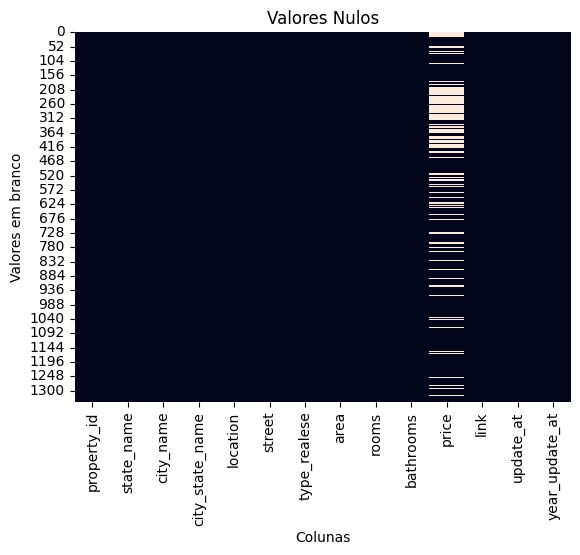

,Coluna,Tipo,Valores_Nulos,Percentual_Nulos
price,price,float64,336,25.055928
property_id,property_id,int64,0,0.000000
city_name,city_name,object,0,0.000000
city_state_name,city_state_name,object,0,0.000000
location,location,object,0,0.000000
state_name,state_name,object,0,0.000000
street,street,object,0,0.000000
type_realese,type_realese,object,0,0.000000
rooms,rooms,object,0,0.000000
area,area,int64,0,0.000000


In [118]:
ax = plt.axes()
sns.heatmap(df_imoveis.isna(), cbar=False, ax=ax)
plt.title("Valores Nulos", fontsize=12)
plt.xlabel('Colunas', fontsize = 10) 
plt.ylabel('Valores em branco', fontsize = 10)
plt.show()

null_analysis = pd.DataFrame({
        'Coluna': df_imoveis.columns,
        'Tipo': df_imoveis.dtypes,
        'Valores_Nulos': df_imoveis.isnull().sum(),
        'Percentual_Nulos': (df_imoveis.isnull().sum() / len(df_imoveis)) * 100
    })

null_analysis.sort_values('Percentual_Nulos', ascending=False)

## 2.3 Tabela de resumo

### 2.3.1 Visão Geral

In [52]:
df.describe(include='all').round(2)

,state_name,city_name,update_at_imoveis,qtd_imoveis,qtd_type_realese_planta,qtd_type_realese_construcao,qtd_type_realese_pronto,qtd_type_realese_outros,qtd_imoveis_price,avg_price,...,unidades_locais_value,pessoal_ocupado_year,pessoal_ocupado_unidade,pessoal_ocupado_value,salario_medio_year,salario_medio_unidade,salario_medio_value,ensino_superior_year,ensino_superior_unidade,ensino_superior_value
count,18,18,18,18.00,18.00,18.00,18.00,18.0,18.00,18.00,...,18.00,18,18,18.00,18,18,18.00,18,18,18.00
unique,18,18,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,1,1,NaN,1,1,NaN,1,1,NaN
top,AM,Manaus,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,2022,Pessoas,NaN,2022,Reais,NaN,2022,Pessoas,NaN
freq,1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,18,18,NaN,18,18,NaN,18,18,NaN
mean,NaN,NaN,2025-03-22 17:01:01+00:00,74.50,29.44,26.11,18.94,0.0,55.83,705835.14,...,172581.67,NaN,NaN,1171196.06,NaN,NaN,4285.62,NaN,NaN,473569.06
min,NaN,NaN,2025-03-22 17:01:01+00:00,1.00,0.00,0.00,0.00,0.0,1.00,317177.67,...,36484.00,NaN,NaN,262574.00,NaN,NaN,3236.56,NaN,NaN,98406.00
25%,NaN,NaN,2025-03-22 17:01:01+00:00,6.25,1.00,3.25,0.25,0.0,3.75,465327.28,...,51123.00,NaN,NaN,359401.50,NaN,NaN,3694.26,NaN,NaN,166582.50
50%,NaN,NaN,2025-03-22 17:01:01+00:00,14.00,3.50,5.50,1.50,0.0,8.50,671910.52,...,96320.50,NaN,NaN,781689.50,NaN,NaN,4220.33,NaN,NaN,308269.50
75%,NaN,NaN,2025-03-22 17:01:01+00:00,28.25,9.50,12.00,12.25,0.0,28.00,942620.37,...,179001.00,NaN,NaN,1127895.25,NaN,NaN,4724.21,NaN,NaN,454823.00
max,NaN,NaN,2025-03-22 17:01:01+00:00,783.00,231.00,316.00,236.00,0.0,685.00,1202500.00,...,1114100.00,NaN,NaN,6728485.00,NaN,NaN,5902.12,NaN,NaN,2512570.00


###  2.3.2 Tipos das colunas

In [53]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18 entries, 0 to 17
Data columns (total 34 columns):
 #   Column                       Non-Null Count  Dtype              
---  ------                       --------------  -----              
 0   state_name                   18 non-null     object             
 1   city_name                    18 non-null     object             
 2   update_at_imoveis            18 non-null     datetime64[ns, UTC]
 3   qtd_imoveis                  18 non-null     int64              
 4   qtd_type_realese_planta      18 non-null     int64              
 5   qtd_type_realese_construcao  18 non-null     int64              
 6   qtd_type_realese_pronto      18 non-null     int64              
 7   qtd_type_realese_outros      18 non-null     int64              
 8   qtd_imoveis_price            18 non-null     int64              
 9   avg_price                    18 non-null     float64            
 10  qtd_area                     18 non-null     int64  

### 2.3.3 Valores Nulos

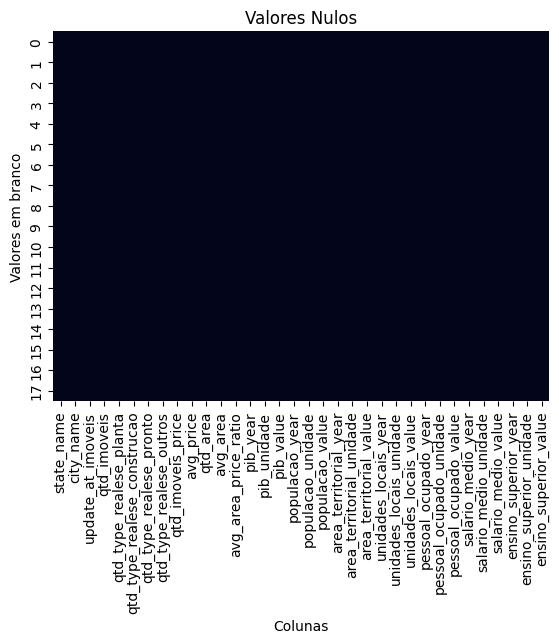

,Coluna,Tipo,Valores_Nulos,Percentual_Nulos
state_name,state_name,object,0,0.0
city_name,city_name,object,0,0.0
update_at_imoveis,update_at_imoveis,"datetime64[ns, UTC]",0,0.0
qtd_imoveis,qtd_imoveis,int64,0,0.0
qtd_type_realese_planta,qtd_type_realese_planta,int64,0,0.0
qtd_type_realese_construcao,qtd_type_realese_construcao,int64,0,0.0
qtd_type_realese_pronto,qtd_type_realese_pronto,int64,0,0.0
qtd_type_realese_outros,qtd_type_realese_outros,int64,0,0.0
qtd_imoveis_price,qtd_imoveis_price,int64,0,0.0
avg_price,avg_price,float64,0,0.0


In [54]:
ax = plt.axes()
sns.heatmap(df.isna(), cbar=False, ax=ax)
plt.title("Valores Nulos", fontsize=12)
plt.xlabel('Colunas', fontsize = 10) 
plt.ylabel('Valores em branco', fontsize = 10)
plt.show()

null_analysis = pd.DataFrame({
        'Coluna': df.columns,
        'Tipo': df.dtypes,
        'Valores_Nulos': df.isnull().sum(),
        'Percentual_Nulos': (df.isnull().sum() / len(df)) * 100
    })

null_analysis.sort_values('Percentual_Nulos', ascending=False)

# 3 Análise de Dados

## 3.1 Cidades com lançamentos no ZapImoveis

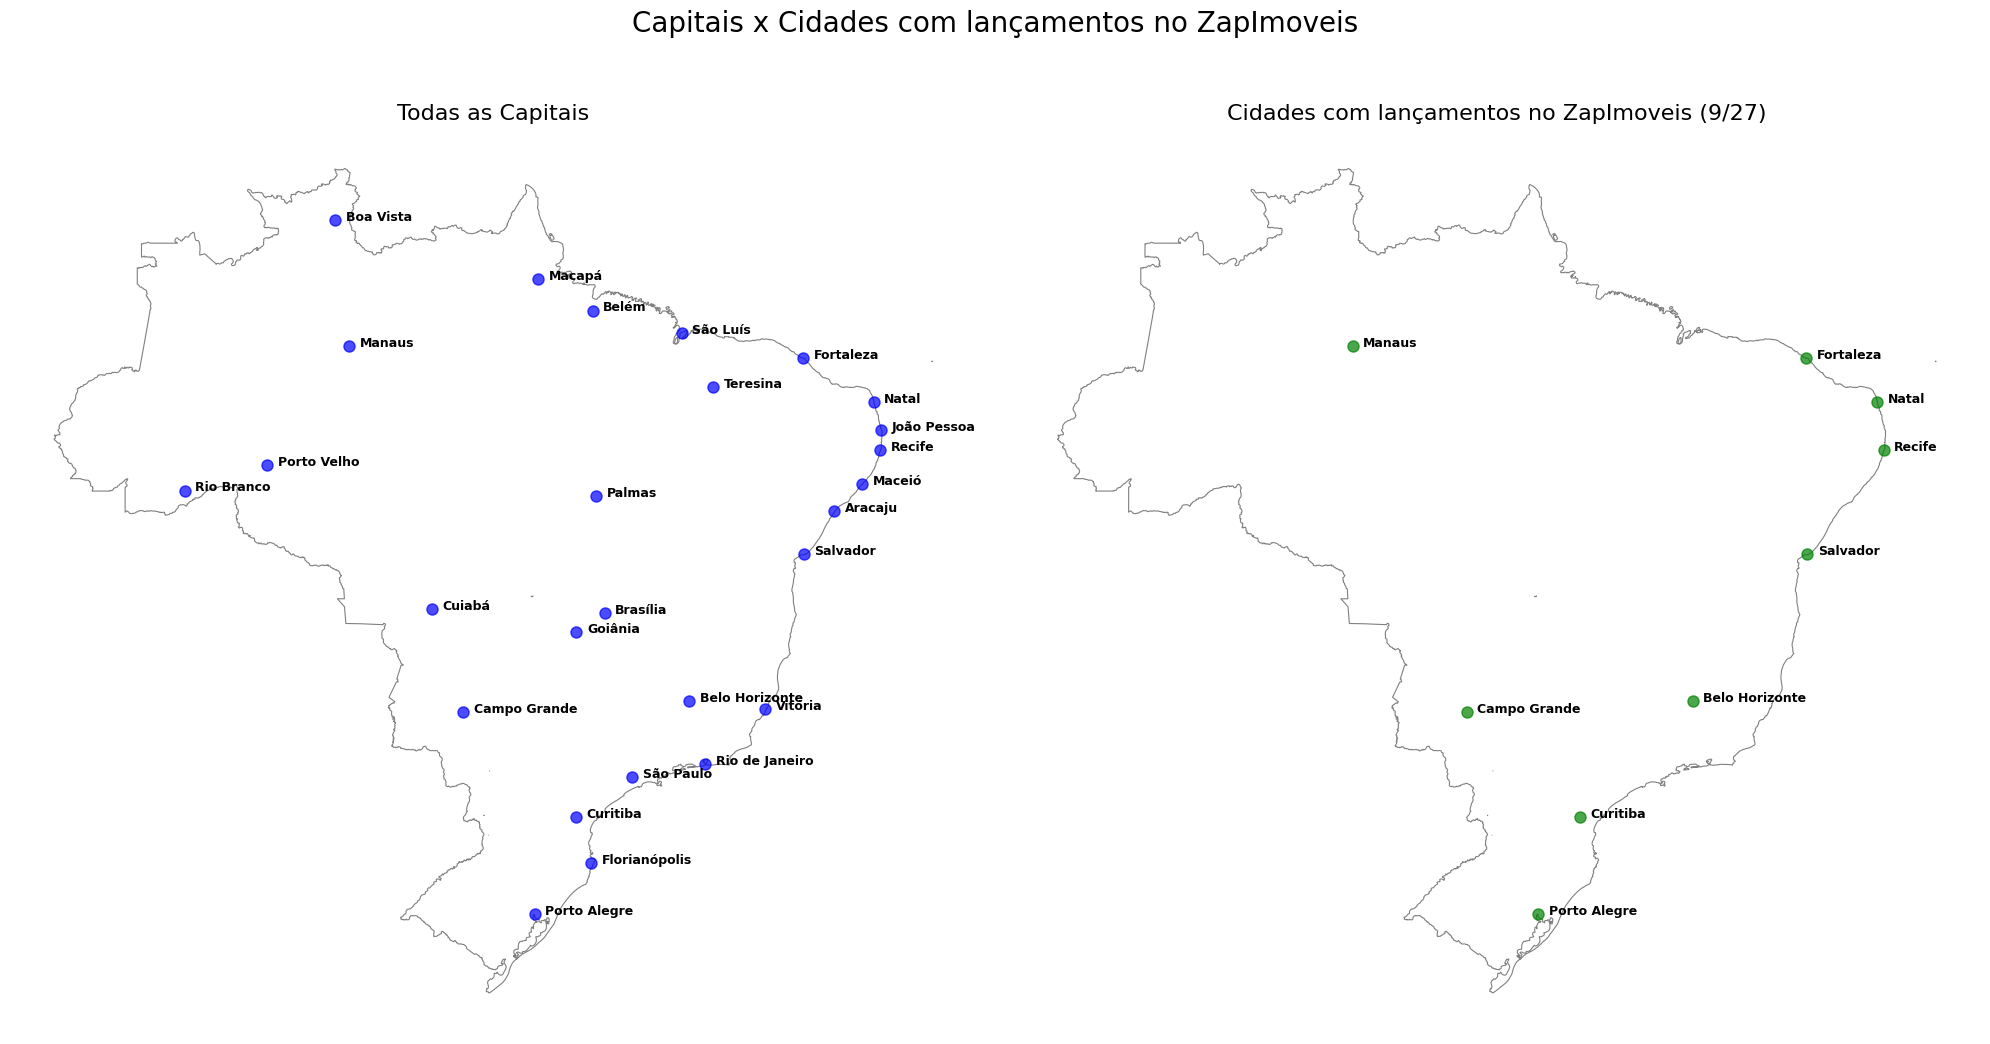

In [ ]:
# 1. Baixar o GeoJSON do Brasil
url_brasil = "https://servicodados.ibge.gov.br/api/v3/malhas/paises/BR?formato=application/vnd.geo+json&resolucao=5"
response = requests.get(url_brasil)
geojson = response.json()
gdf_brasil = gpd.GeoDataFrame.from_features(geojson["features"])

# 2. Dicionário de capitais (exemplo completo)
capitais = {
    "Rio Branco": (-9.9747, -67.8100), "Maceió": (-9.6657, -35.7350),"Macapá": (0.0349, -51.0664),"Manaus": (-3.1190, -60.0217),"Salvador": (-12.9714, -38.5014),"Fortaleza": (-3.7172, -38.5433),
    "Brasília": (-15.7797, -47.9297),"Vitória": (-20.3194, -40.3378),"Goiânia": (-16.6869, -49.2648),"São Luís": (-2.5387, -44.2828),"Cuiabá": (-15.6010, -56.0974),"Campo Grande": (-20.4697, -54.6201),
    "Belo Horizonte": (-19.9167, -43.9345),"Belém": (-1.4558, -48.4902),"João Pessoa": (-7.1195, -34.8450),"Curitiba": (-25.4296, -49.2713),"Recife": (-8.0543, -34.8813),"Teresina": (-5.0892, -42.8016),
    "Rio de Janeiro": (-22.9068, -43.1729),"Natal": (-5.7793, -35.2009),"Porto Alegre": (-30.0331, -51.2300),"Porto Velho": (-8.7612, -63.9004),"Boa Vista": (2.8238, -60.6758),"Florianópolis": (-27.5969, -48.5495),
    "São Paulo": (-23.5505, -46.6333),"Aracaju": (-10.9472, -37.0731),"Palmas": (-10.2491, -48.3243)
}

capitais_filtradas = {cidade: coord for cidade, coord in capitais.items() 
                      if cidade in df["city_name"].values}


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))

# Mapa 1: Todas as capitais
gdf_brasil.boundary.plot(ax=ax1, linewidth=0.8, color="gray")
for cidade, (lat, lon) in capitais.items():
    ax1.plot(lon, lat, 'bo', markersize=8, alpha=0.7)
    ax1.text(lon + 0.5, lat, cidade, fontsize=9, weight='bold', ha='left')
ax1.set_title("Todas as Capitais", fontsize=16)
ax1.set_axis_off()

# Mapa 2: Cidades com imóveis no ZapImoveis
gdf_brasil.boundary.plot(ax=ax2, linewidth=0.8, color="gray")
for cidade, (lat, lon) in capitais_filtradas.items():
    ax2.plot(lon, lat, 'go', markersize=8, alpha=0.7) 
    ax2.text(lon + 0.5, lat, cidade, fontsize=9, weight='bold', ha='left')
ax2.set_title(f"Cidades com lançamentos no ZapImoveis ({len(capitais_filtradas)}/27)", fontsize=16)
ax2.set_axis_off()

plt.suptitle("Capitais x Cidades com lançamentos no ZapImoveis", fontsize=20, y=1.05)
plt.tight_layout()
plt.show()

## 3.2 Número de Imóveis por Cidade e Tipo de Lançamento

In [ ]:
# Transformação para formato longo
df_melted = pd.melt(
    df,
    id_vars=['city_name', 'qtd_imoveis'],
    value_vars=[
        'qtd_type_realese_planta',
        'qtd_type_realese_construcao',
        'qtd_type_realese_pronto',
        'qtd_type_realese_outros'
    ],
    var_name='Tipo de Lançamento',
    value_name='Quantidade'
)

# Cria o gráfico de barras empilhadas SEM o texto repetido
fig = px.bar(
    df_melted,
    x='city_name',
    y='Quantidade',
    color='Tipo de Lançamento',
    title='Quantidade de Imóveis por Cidade e Tipo de Lançamento',
    labels={'city_name': 'Cidade', 'Quantidade': 'Quantidade de Imóveis'},
    hover_data={'city_name': True, 'Quantidade': True, 'Tipo de Lançamento': True},
)

# Layout com barras empilhadas
fig.update_layout(
    barmode='stack',
    hovermode='x unified',
    xaxis={'categoryorder': 'total descending'}
)

# Valor do Total
for city, total in zip(df['city_name'], df['qtd_imoveis']):
    fig.add_annotation(
        x=city,
        y=total,
        text=str(total),
        showarrow=False,
        yshift=10,  # Ajusta a posição vertical
        font=dict(size=12, color='black')
    )

# Tooltip
fig.update_traces(
    hovertemplate=
                  "<b>Tipo:</b> %{fullData.name}<br>" +
                  "<b>Quantidade:</b> %{y}<br>",
    customdata=df_melted[['qtd_imoveis']]
)

fig.show()

## 3.3 Boxplot do Preço dos Imóveis por Cidade

In [ ]:
df_imoveis_interesse = df_imoveis[df_imoveis['price']>0]

fig = px.box(
    df_imoveis_interesse,
    x="city_name",  
    y="price",    
    title="Distribuição de Preços por Cidade",
    labels={"city_name": "Cidade", "price": "Preço"},
    color="city_name", 
    hover_data=["state_name"]
)

fig.update_layout(
    xaxis_title="Cidade",
    yaxis_title="Preço",
    showlegend=False,
    hovermode="x unified" 
)

# Anotações
fig.update_traces(
    hovertemplate="<b>Preço:</b> %{y:,.2f}<br>"
)

fig.show()

## 3.4 Média dos preços por Cidade

In [ ]:
import plotly.graph_objects as go

df_sorted = df.sort_values(by='avg_price', ascending=False)

fig = go.Figure()

fig.add_trace(go.Bar(
    x=df_sorted['city_name'], 
    y=df_sorted['avg_price'], 
    name='Preço Médio',
    marker_color='skyblue'
))

# Anotações
for i, value in enumerate(df_sorted['avg_price']):
    fig.add_annotation(
        x=df_sorted['city_name'].iloc[i], 
        y=value, 
        text=f'{value:.2f}',
        showarrow=False, 
        font=dict(size=12, color='black'),
        yshift=10
    )

fig.update_layout(
    title='Preço Médio por Cidade',
    xaxis_title='Cidade',
    yaxis_title='Preço Médio',
    showlegend=False
)

fig.show()


## 3.5 Média do preço por m² por Cidade

In [98]:
df_sorted = df.sort_values(by='avg_area_price_ratio', ascending=False)

colors = ['skyblue'] * len(df_sorted)
colors[:4] = ['#2ca02c'] * 4
colors[-4:] = ['#d62728'] * 4 

fig = go.Figure()

fig.add_trace(go.Bar(
    x=df_sorted['city_name'], 
    y=df_sorted['avg_area_price_ratio'], 
    name='Preço Médio do m²',
    marker_color=colors
))

# Anotações
for i, value in enumerate(df_sorted['avg_area_price_ratio']):
    fig.add_annotation(
        x=df_sorted['city_name'].iloc[i], 
        y=value, 
        text=f'{value:.2f}', 
        showarrow=False, 
        font=dict(size=12, color='black'),
        yshift=10 
    )

fig.update_layout(
    title='Preço Médio do m² por cidade',
    xaxis_title='Cidade',
    yaxis_title='Preço Médio do m²',
    showlegend=False
)

fig.show()


## 3.6 Correlação

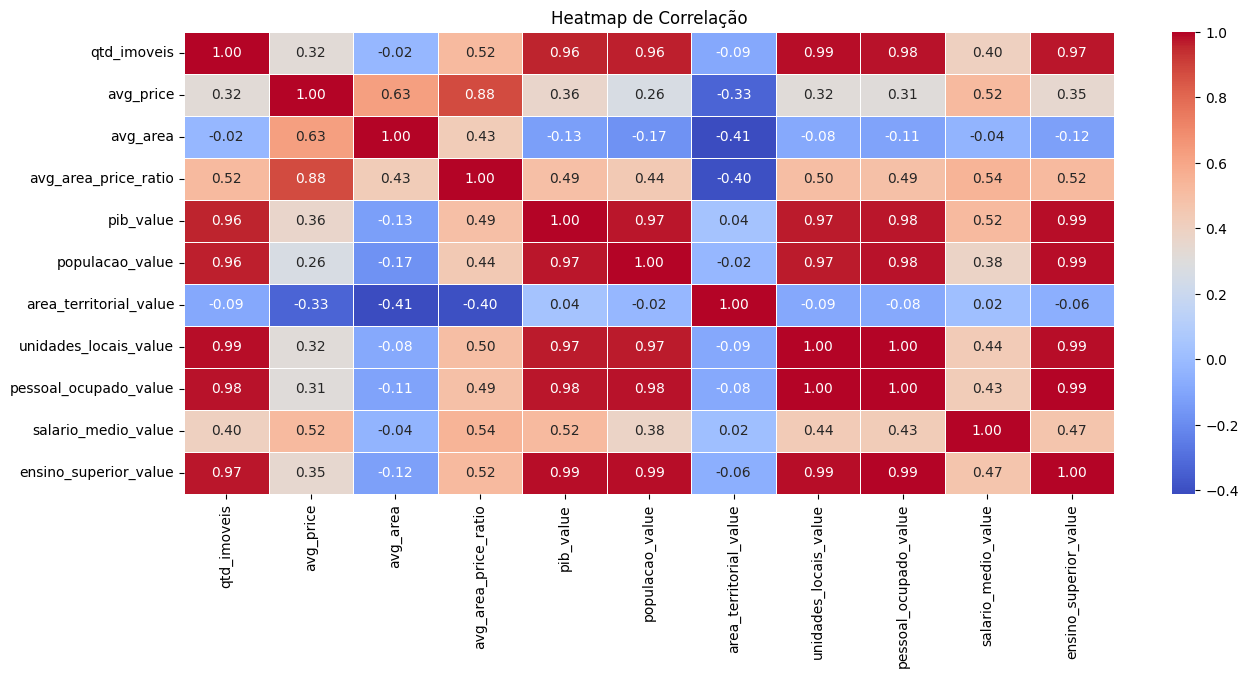

In [71]:
columns = [
    'qtd_imoveis', 'avg_price', 'avg_area', 'avg_area_price_ratio', 
    'pib_value', 'populacao_value', 'area_territorial_value', 
    'unidades_locais_value', 'pessoal_ocupado_value', 'salario_medio_value', 
    'ensino_superior_value'
]

df_interesse = df[columns]

corr_matrix = df_interesse.corr()

plt.figure(figsize=(15, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', cbar=True, linewidths=0.5)
plt.title('Heatmap de Correlação')
plt.show()


## 3.7 PIB por Cidade

In [107]:
df_sorted = df.sort_values(by='avg_area_price_ratio', ascending=False)

colors = ['skyblue'] * len(df_sorted)
colors[:4] = ['#2ca02c'] * 4
colors[-4:] = ['#d62728'] * 4 

df_sorted['color'] = colors

df_sorted = df_sorted.sort_values(by='pib_value', ascending=False)

fig = go.Figure()

fig.add_trace(go.Bar(
    x=df_sorted['city_name'], 
    y=df_sorted['pib_value'], 
    name='PIB por cidade',
    marker_color=df_sorted['color']
))

# Anotações
for i, value in enumerate(df_sorted['pib_value']):
    fig.add_annotation(
        x=df_sorted['city_name'].iloc[i], 
        y=value, 
        text=f'{value:.2f}', 
        showarrow=False, 
        font=dict(size=12, color='black'),
        yshift=10 
    )

fig.update_layout(
    title='PIB por cidade (em verde os 4 maiores e em vermelho os 4 menores em relação ao preço do m²)',
    xaxis_title='Cidade',
    yaxis_title='PIB por cidade',
    showlegend=False
)

fig.show()


## 3.8 População por Cidade

In [106]:
df_sorted = df.sort_values(by='avg_area_price_ratio', ascending=False)

colors = ['skyblue'] * len(df_sorted)
colors[:4] = ['#2ca02c'] * 4
colors[-4:] = ['#d62728'] * 4 

df_sorted['color'] = colors

df_sorted = df_sorted.sort_values(by='populacao_value', ascending=False)

fig = go.Figure()

fig.add_trace(go.Bar(
    x=df_sorted['city_name'], 
    y=df_sorted['populacao_value'], 
    name='População por cidade',
    marker_color=df_sorted['color']
))

# Anotações
for i, value in enumerate(df_sorted['populacao_value']):
    fig.add_annotation(
        x=df_sorted['city_name'].iloc[i], 
        y=value, 
        text=f'{value:.2f}', 
        showarrow=False, 
        font=dict(size=12, color='black'),
        yshift=10 
    )

fig.update_layout(
    title='População por cidade (em verde os 4 maiores e em vermelho os 4 menores em relação ao preço do m²)',
    xaxis_title='Cidade',
    yaxis_title='População por cidade',
    showlegend=False
)

fig.show()


## 3.9 Área territorial

In [105]:
df_sorted = df.sort_values(by='avg_area_price_ratio', ascending=False)

colors = ['skyblue'] * len(df_sorted)
colors[:4] = ['#2ca02c'] * 4
colors[-4:] = ['#d62728'] * 4 

df_sorted['color'] = colors

df_sorted = df_sorted.sort_values(by='area_territorial_value', ascending=False)

fig = go.Figure()

fig.add_trace(go.Bar(
    x=df_sorted['city_name'], 
    y=df_sorted['area_territorial_value'], 
    name='Área territorial por cidade',
    marker_color=df_sorted['color']
))

# Anotações
for i, value in enumerate(df_sorted['area_territorial_value']):
    fig.add_annotation(
        x=df_sorted['city_name'].iloc[i], 
        y=value, 
        text=f'{value:.2f}', 
        showarrow=False, 
        font=dict(size=12, color='black'),
        yshift=10 
    )

fig.update_layout(
    title='Área territorial por cidade (em verde os 4 maiores e em vermelho os 4 menores em relação ao preço do m²) - Inversamente',
    xaxis_title='Cidade',
    yaxis_title='Área territorial por cidade',
    showlegend=False
)

fig.show()


## 3.10 Unidades Locais

In [111]:
df_sorted = df.sort_values(by='avg_area_price_ratio', ascending=False)

colors = ['skyblue'] * len(df_sorted)
colors[:4] = ['#2ca02c'] * 4
colors[-4:] = ['#d62728'] * 4 

df_sorted['color'] = colors

df_sorted = df_sorted.sort_values(by='unidades_locais_value', ascending=False)

fig = go.Figure()

fig.add_trace(go.Bar(
    x=df_sorted['city_name'], 
    y=df_sorted['unidades_locais_value'], 
    name='Unidades Locais por cidade',
    marker_color=df_sorted['color']
))

# Anotações
for i, value in enumerate(df_sorted['unidades_locais_value']):
    fig.add_annotation(
        x=df_sorted['city_name'].iloc[i], 
        y=value, 
        text=f'{value:.2f}', 
        showarrow=False, 
        font=dict(size=12, color='black'),
        yshift=10 
    )

fig.update_layout(
    title='Unidades Locais por cidade (em verde os 4 maiores e em vermelho os 4 menores em relação ao preço do m²)',
    xaxis_title='Cidade',
    yaxis_title='Unidades Locais por cidade',
    showlegend=False
)

fig.show()


## 3.11 Pessoal Ocupado

In [113]:
df_sorted = df.sort_values(by='avg_area_price_ratio', ascending=False)

colors = ['skyblue'] * len(df_sorted)
colors[:4] = ['#2ca02c'] * 4
colors[-4:] = ['#d62728'] * 4 

df_sorted['color'] = colors

df_sorted = df_sorted.sort_values(by='pessoal_ocupado_value', ascending=False)

fig = go.Figure()

fig.add_trace(go.Bar(
    x=df_sorted['city_name'], 
    y=df_sorted['pessoal_ocupado_value'], 
    name='Pessoal ocupado por cidade',
    marker_color=df_sorted['color']
))

# Anotações
for i, value in enumerate(df_sorted['pessoal_ocupado_value']):
    fig.add_annotation(
        x=df_sorted['city_name'].iloc[i], 
        y=value, 
        text=f'{value:.2f}', 
        showarrow=False, 
        font=dict(size=12, color='black'),
        yshift=10 
    )

fig.update_layout(
    title='Pessoal ocupado por cidade (em verde os 4 maiores e em vermelho os 4 menores em relação ao preço do m²)',
    xaxis_title='Cidade',
    yaxis_title='Pessoal ocupado por cidade',
    showlegend=False
)

fig.show()


## 3.12 Salário Médio

In [115]:
df_sorted = df.sort_values(by='avg_area_price_ratio', ascending=False)

colors = ['skyblue'] * len(df_sorted)
colors[:4] = ['#2ca02c'] * 4
colors[-4:] = ['#d62728'] * 4 

df_sorted['color'] = colors

df_sorted = df_sorted.sort_values(by='salario_medio_value', ascending=False)

fig = go.Figure()

fig.add_trace(go.Bar(
    x=df_sorted['city_name'], 
    y=df_sorted['salario_medio_value'], 
    name='Salário Médio por cidade',
    marker_color=df_sorted['color']
))

# Anotações
for i, value in enumerate(df_sorted['salario_medio_value']):
    fig.add_annotation(
        x=df_sorted['city_name'].iloc[i], 
        y=value, 
        text=f'{value:.2f}', 
        showarrow=False, 
        font=dict(size=12, color='black'),
        yshift=10 
    )

fig.update_layout(
    title='Salário Médio por cidade (em verde os 4 maiores e em vermelho os 4 menores em relação ao preço do m²)',
    xaxis_title='Cidade',
    yaxis_title='Salário Médio por cidade',
    showlegend=False
)

fig.show()


## 3.13 Ensino Superior

In [116]:
df_sorted = df.sort_values(by='avg_area_price_ratio', ascending=False)

colors = ['skyblue'] * len(df_sorted)
colors[:4] = ['#2ca02c'] * 4
colors[-4:] = ['#d62728'] * 4 

df_sorted['color'] = colors

df_sorted = df_sorted.sort_values(by='ensino_superior_value', ascending=False)

fig = go.Figure()

fig.add_trace(go.Bar(
    x=df_sorted['city_name'], 
    y=df_sorted['ensino_superior_value'], 
    name='Pessoas com ensino superior por cidade',
    marker_color=df_sorted['color']
))

# Anotações
for i, value in enumerate(df_sorted['ensino_superior_value']):
    fig.add_annotation(
        x=df_sorted['city_name'].iloc[i], 
        y=value, 
        text=f'{value:.2f}', 
        showarrow=False, 
        font=dict(size=12, color='black'),
        yshift=10 
    )

fig.update_layout(
    title='Pessoas com ensino superior por cidade (em verde os 4 maiores e em vermelho os 4 menores em relação ao preço do m²)',
    xaxis_title='Cidade',
    yaxis_title='Pessoas com ensino superior por cidade',
    showlegend=False
)

fig.show()
